In [1]:
import oefp
import oepandas as oepd
import cnotebook
from openeye import oechem

# OEFP: Enhanced OpenEye Fingerprints

## Simple Fingerprint Comparison

Let's start nice and easy with a 3 molecule example.

In [2]:
# Create the molecules
mol1 = oechem.OEGraphMol()
mol2 = oechem.OEGraphMol()
mol3 = oechem.OEGraphMol()

oechem.OESmilesToMol(mol1, "c1ccc(cc1)Cc2c3c(cc(cn3)OCCCN4CCCCC4)ncn2")
oechem.OESmilesToMol(mol2, "c1ccc(cc1)Nc2c3ccc(cc3ncn2)OCCC4CCNCC4")
oechem.OESmilesToMol(mol3, "c1ccc(cc1)C[C@@H](C(=O)O)NC(=O)c2cc(cc(c2)Cl)Cl")

# Let's see what they look like
cnotebook.molgrid([mol1, mol2, mol3]).display()

Clearly you can see that `mol1` and `mol2` are more similar to each other than `mol3`. Let's show that using simple Tanimoto comparisons.

In [3]:
fp1 = oefp.morgan_fingerprint(mol1, num_bits=1024)
fp2 = oefp.morgan_fingerprint(mol2, num_bits=1024)
fp3 = oefp.morgan_fingerprint(mol3, num_bits=1024)

In [4]:
print("mol1 vs mol2", oefp.compare(fp1, fp2, oefp.Metric.tanimoto()))
print("mol1 vs mol3", oefp.compare(fp1, fp3, oefp.Metric.tanimoto()))
print("mol2 vs mol3", oefp.compare(fp2, fp3, oefp.Metric.tanimoto()))

mol1 vs mol2 0.26666666666666666
mol1 vs mol3 0.136986301369863
mol2 vs mol3 0.12


Let's read in a handful of drugs approved bewteen 2004-2006. We'll create both molecules and standard 1024 bit Morgan fingerprints.

In [5]:
mols = []
fps = []

# Read molecules using the OpenEye Toolkits
with oechem.oemolistream("assets/two_series.sdf") as ifs:
    for mol in ifs.GetOEGraphMols():

        # Save a copy of the molecule in our list
        mols.append(oechem.OEGraphMol(mol))

        # Create Morgan fingerprints
        fp = oefp.morgan_fingerprint(mol, num_bits=1024)
        fps.append(fp)

Let's take a look at the molecule that we just read in.

In [6]:
cnotebook.molgrid(mols).display()

In [7]:
oechem.OEMolToSmiles(mols[0])

'c1ccc(cc1)C[C@@H](C(=O)O)NC(=O)c2cc(cc(c2)Cl)Cl'

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x166aa3c60> >
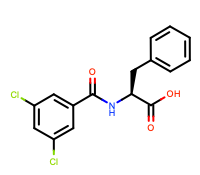

In [8]:
mols[0]

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x166aa38d0> >
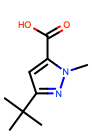

In [9]:
mols[3]